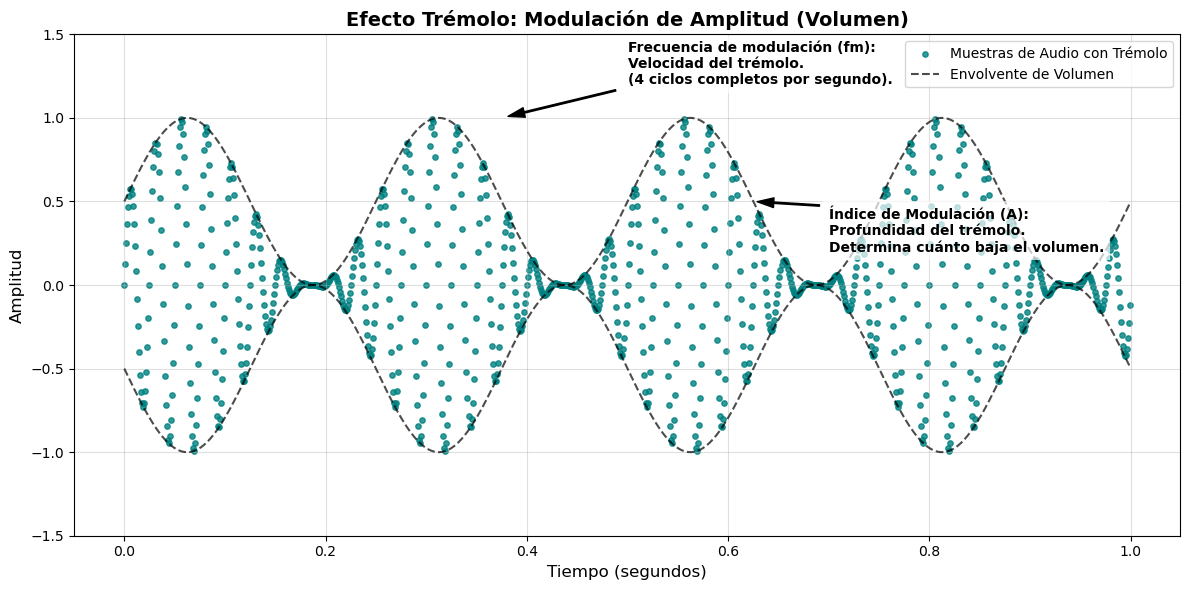

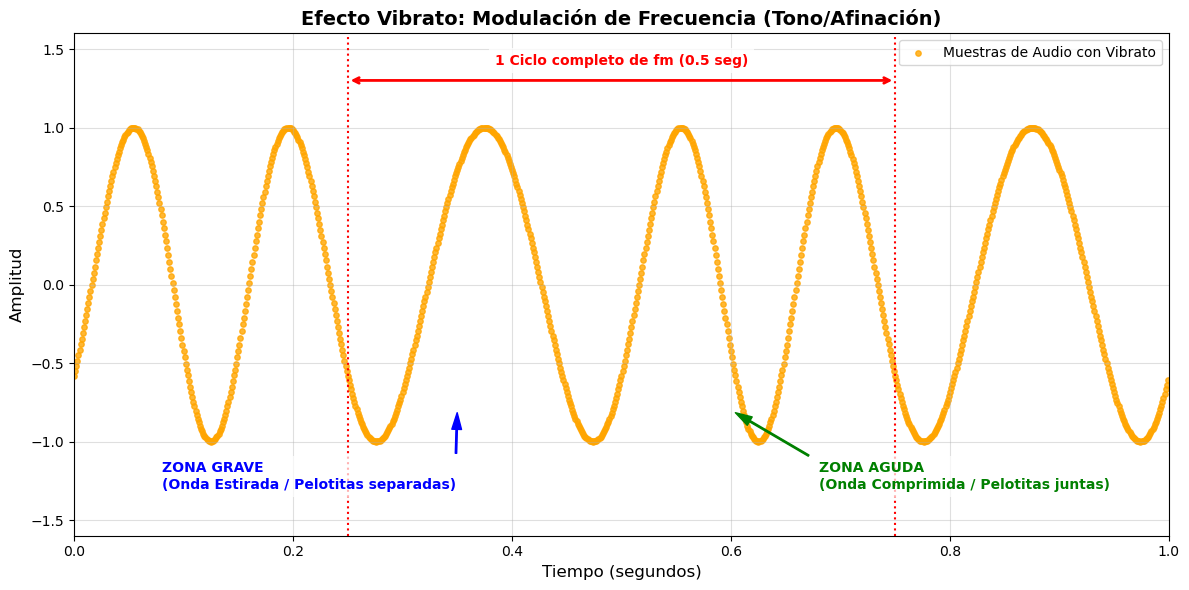


¡Listo! Las imágenes 'grafica_tremolo.png' y 'grafica_vibrato.png' se han guardado con éxito.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- Configuración global para que las gráficas salgan bonitas en la memoria ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['grid.alpha'] = 0.4
plt.rcParams['savefig.dpi'] = 300  # Alta resolución para la memoria

fs = 1000  # Frecuencia de muestreo simulada
duracion = 1.0  # 1 segundo de duración
t = np.linspace(0, duracion, int(fs * duracion), endpoint=False)


# ==============================================================================
# 1. GRÁFICA DE TRÉMOLO (Configuración óptima para Modulación de Amplitud)
# ==============================================================================
fc_tremolo = 40  # Frecuencia de la portadora alta para ver la silueta del volumen
fm_tremolo = 4   # 4 oscilaciones de volumen por segundo

carreadora_tremolo = np.sin(2 * np.pi * fc_tremolo * t)
A_tremolo = 1.0  # Máxima profundidad (100%)

# Basado en tu código de tremolo.cpp
lfo_tremolo = np.sin(2 * np.pi * fm_tremolo * t)
envolvente_tremolo = ((2 - A_tremolo) + A_tremolo * lfo_tremolo) / 2
tremolo_señal = carreadora_tremolo * envolvente_tremolo

plt.figure(figsize=(12, 6))

# Muestras discretas (pelotitas teal)
plt.scatter(t, tremolo_señal, color='teal', s=15, alpha=0.8, label='Muestras de Audio con Trémolo')

# Envolvente exterior discontinua
plt.plot(t, envolvente_tremolo, color='black', linestyle='--', alpha=0.7, label='Envolvente de Volumen')
plt.plot(t, -envolvente_tremolo, color='black', linestyle='--', alpha=0.7)

# Anotaciones explicativas en el Trémolo
plt.annotate('Índice de Modulación (A):\nProfundidad del trémolo.\nDetermina cuánto baja el volumen.',
             xy=(0.625, 0.5), xytext=(0.7, 0.2),
             arrowprops=dict(facecolor='black', edgecolor='black', shrink=0.05, width=1, headwidth=7),
             fontsize=10, ha='left', fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.annotate('Frecuencia de modulación (fm):\nVelocidad del trémolo.\n(4 ciclos completos por segundo).',
             xy=(0.375, 1.0), xytext=(0.5, 1.2),
             arrowprops=dict(facecolor='black', edgecolor='black', shrink=0.05, width=1, headwidth=7),
             fontsize=10, ha='left', fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.title("Efecto Trémolo: Modulación de Amplitud (Volumen)")
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Amplitud")
plt.ylim(-1.5, 1.5)
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("grafica_tremolo.png")
plt.show()


# ==============================================================================
# 2. GRÁFICA DE VIBRATO (Configuración óptima para Modulación de Frecuencia)
# ==============================================================================
# ¡Clave! Bajamos fc a 6 y fm a 2 para que el acordeón se estire y se lea perfectamente
fc_vibrato = 6   
fm_vibrato = 2   

I_semitonos = 4.0 
I_linear = 1.0 - pow(2, -I_semitonos / 12.0)

# Simulación matemática de FM (Vibrato) basada en vibrato.cpp
fase_fm = 2 * np.pi * fc_vibrato * t - (fc_vibrato * I_linear / fm_vibrato) * np.cos(2 * np.pi * fm_vibrato * t)
vibrato_señal = np.sin(fase_fm)

plt.figure(figsize=(12, 6))

# Muestras discretas (pelotitas naranjas)
plt.scatter(t, vibrato_señal, color='orange', s=15, alpha=0.8, label='Muestras de Audio con Vibrato')

# Líneas guía rojas para marcar de forma limpia 1 ciclo completo de FM (0.25s a 0.75s)
plt.axvline(0.25, color='red', linestyle=':', linewidth=1.5)
plt.axvline(0.75, color='red', linestyle=':', linewidth=1.5)

# Flecha horizontal indicando la duración de 1 ciclo completo de fm (2 Hz = 0.5 seg)
plt.annotate('', xy=(0.25, 1.3), xytext=(0.75, 1.3),
             arrowprops=dict(arrowstyle='<->', color='red', linewidth=2))
plt.text(0.5, 1.4, '1 Ciclo completo de fm (0.5 seg)', fontsize=10, ha='center', 
         fontweight='bold', color='red', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Anotaciones de estiramiento y compresión (Índice de modulación)
plt.annotate('ZONA AGUDA\n(Onda Comprimida / Pelotitas juntas)',
             xy=(0.60, -0.8), xytext=(0.68, -1.3),
             arrowprops=dict(facecolor='green', edgecolor='green', shrink=0.05, width=1, headwidth=7),
             fontsize=10, ha='left', fontweight='bold', color='green', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.annotate('ZONA GRAVE\n(Onda Estirada / Pelotitas separadas)',
             xy=(0.35, -0.8), xytext=(0.08, -1.3),
             arrowprops=dict(facecolor='blue', edgecolor='blue', shrink=0.05, width=1, headwidth=7),
             fontsize=10, ha='left', fontweight='bold', color='blue', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.title("Efecto Vibrato: Modulación de Frecuencia (Tono/Afinación)")
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Amplitud")
plt.xlim(0.0, 1.0)
plt.ylim(-1.6, 1.6)
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("grafica_vibrato.png")
plt.show()

print("\n¡Listo! Las imágenes 'grafica_tremolo.png' y 'grafica_vibrato.png' se han guardado con éxito.")